# Data Cleaning and Initial Exploration

**Dataset:** Financial PhraseBank (`Sentences_75Agree`, ~3.4k samples)  

---
**Outputs saved to Google Drive:**
- `processed_phrasebank.csv` — cleaned dataset with all features
- `train.csv`, `val.csv`, `test.csv` — stratified splits (70/15/15)
- `eda_figures/` — all EDA plots

---
## 1. Install Dependencies

In [1]:
%%capture
!pip install -q datasets spacy textstat scipy matplotlib seaborn wordcloud
!python -m spacy download en_core_web_trf -q

---
## 2. Mount Google Drive & Configure Paths

In [2]:
from google.colab import drive
import os

# Mount drive - will access shared project folder
drive.mount('/content/drive', force_remount=False)

# Paths to be used in notebook
# NEED TO ADD SHORTCUT TO SHARED FOLDER: "My Drive" -> "CSCI 5541 Project"
PROJECT_DIR = '/content/drive/MyDrive/CSCI 5541 Project'
REPO_DIR    = os.path.join(PROJECT_DIR, 'Linguistically-aware-model-routing-for-financial-sentiment-analysis')
OUTPUT_DIR  = os.path.join(PROJECT_DIR, 'processed_data')   # saved here (may be too large for GitHub)
FIG_DIR     = os.path.join(OUTPUT_DIR, 'eda_figures')

# Could not programatically import dataset, saved it to Drive instead
DATA_FILE   = os.path.join(PROJECT_DIR, 'raw_data/Sentences_75Agree.txt')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR,    exist_ok=True)

print(f'Project dir:\t{PROJECT_DIR}')
print(f'Repo dir:\t{REPO_DIR}')
print(f'Output dir:\t{OUTPUT_DIR}')

# Make sure shortcut is in Drive
assert os.path.isdir(PROJECT_DIR), 'PROJECT_DIR shorcut not found in Drive.'

Mounted at /content/drive
Project dir:	/content/drive/MyDrive/CSCI 5541 Project
Repo dir:	/content/drive/MyDrive/CSCI 5541 Project/Linguistically-aware-model-routing-for-financial-sentiment-analysis
Output dir:	/content/drive/MyDrive/CSCI 5541 Project/processed_data


---
## 3. Load Financial PhraseBank (Sentences_75Agree)

In [3]:
import pandas as pd

df = pd.read_csv(
    DATA_FILE,
    sep='@',
    names=['sentence', 'label'],
    encoding='latin-1'
)

print(df.shape)
df.head()

(3453, 2)


,sentence,label
0,"According to Gran , the company has no plans t...",neutral
1,With the new production plant the company woul...,positive
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,"In the third quarter of 2010 , net sales incre...",positive
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive


In [4]:
# Standardize labels (no whitespace + lowercase)
df['label'] = df['label'].str.lower().str.strip()

print('Label distribution:')
print(df['label'].value_counts())
print(f'\nColumns: {df.columns.tolist()}')
print(f'Shape  : {df.shape}')

Label distribution:
label
neutral     2146
positive     887
negative     420
Name: count, dtype: int64

Columns: ['sentence', 'label']
Shape  : (3453, 2)


---
## 4. Data Cleaning

In [5]:
import re

print(f'Before cleaning: {len(df):,} rows')

# Drop nulls
df_cleaned = df.dropna(subset=['sentence', 'label'])

# Drop leading/trailing whitespace
df_cleaned['sentence'] = df_cleaned['sentence'].str.strip()
df_cleaned['label'] = df_cleaned['label'].str.strip()

# Drop empty sentences
df_cleaned = df_cleaned[df_cleaned['sentence'].str.len() > 0]

# Collapse multiple whitespace/newlines
df_cleaned['sentence'] = df_cleaned['sentence'].apply(lambda x: re.sub(r'\s+', ' ', x))

# Drop duplicates
n_before = len(df)
df_cleaned = df_cleaned.drop_duplicates(subset=['sentence'])
print(f'Removed {n_before - len(df_cleaned)} duplicate sentences')

# Reset index to acc for dropped rows
df_cleaned = df_cleaned.reset_index(drop=True)
df_cleaned['id'] = df_cleaned.index

print(f'After cleaning : {len(df_cleaned):,} rows')
df_cleaned.head(5)

Before cleaning: 3,453 rows
Removed 5 duplicate sentences
After cleaning : 3,448 rows


,sentence,label,id
0,"According to Gran , the company has no plans t...",neutral,0
1,With the new production plant the company woul...,positive,1
2,"For the last quarter of 2010 , Componenta 's n...",positive,2
3,"In the third quarter of 2010 , net sales incre...",positive,3
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive,4


In [6]:
print('Cleaned data')
print(f'\tTotal samples:\t{len(df):,}')
print(f'\tNull text:\t\t{df["sentence"].isna().sum()}')
print(f'\tNull labels:\t\t{df["label"].isna().sum()}')
print(f'\tDuplicate samples:\t{df.duplicated().sum()}')

df = df_cleaned

# Handle label display depending on format
if df["label"].dtype == "int64" or df["label"].dtype == "int32":
    inv_label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    unique_labels = sorted(df["label"].map(inv_label_map).unique())
else:
    unique_labels = sorted(df["label"].unique())

print(f'\tUnique labels:\t\t{unique_labels}')
print(f'\tMin sentence len:\t{df["sentence"].str.len().min()}')
print(f'\tMax sentence len:\t{df["sentence"].str.len().max()}')
print(f'\tMedian sentence len:\t{df["sentence"].str.len().median():.0f} chars')

Cleaned data
	Total samples:	3,453
	Null text:		0
	Null labels:		0
	Duplicate samples:	5
	Unique labels:		['negative', 'neutral', 'positive']
	Min sentence len:	9
	Max sentence len:	315
	Median sentence len:	116 chars


---
## 5. Linguistic Feature Extraction

Extract features that might be useful to the model router

| Feature | Description |
|---|---|
| **token_count** | Number of tokens |
| **char_count** | Character length |
| **avg_word_len** | Average word length (lexical complexity proxy) |
| **dep_depth** | Max syntactic dependency tree depth |
| **num_clauses** | Clause count (SBAR/subordinate markers) |
| **negation_count** | Count of negation tokens |
| **hedge_count** | Count of hedging terms |
| **num_entities** | Named entity count |
| **entity_density** | NE count / token count |
| **num_financial_terms** | Count of domain-specific financial terms |
| **flesch_reading_ease** | Readability score (textstat) |
| **flesch_kincaid_grade** | Reading grade level |
| **passive_voice_count** | Passive constructions (complexity signal) |

In [7]:
import spacy
import textstat

# Load transformer pipeline with GPU
spacy.prefer_gpu()
nlp = spacy.load('en_core_web_trf')
print(f'spaCy pipeline components: {nlp.pipe_names}')
print(f'GPU enabled: {spacy.prefer_gpu()}')

spaCy pipeline components: ['transformer', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
GPU enabled: True


In [8]:
# Financial domain terms - generated by Claude

FINANCIAL_TERMS = {
  # Performance / results
  'revenue', 'profit', 'earnings', 'ebitda', 'ebit', 'margin', 'yield',
  'dividend', 'eps', 'diluted', 'operating', 'net income', 'gross profit',
  'free cash flow', 'capex', 'depreciation', 'amortization', 'impairment',
  # Guidance / forecasting
  'guidance', 'outlook', 'forecast', 'projection', 'estimate', 'target',
  'consensus', 'beat', 'miss', 'revised', 'raised', 'lowered',
  # Market / valuation
  'market cap', 'valuation', 'p/e', 'price-to-earnings', 'book value',
  'enterprise value', 'ipo', 'acquisition', 'merger', 'divestiture',
  'buyback', 'repurchase', 'shares outstanding',
  # Risk / macro
  'liquidity', 'solvency', 'default', 'credit rating', 'downgrade',
  'upgrade', 'leverage', 'debt', 'covenant', 'maturity', 'yield curve',
  'inflation', 'interest rate', 'federal reserve', 'monetary policy',
  # Sectors
  'semiconductor', 'pharmaceutical', 'biotech', 'fintech', 'saas',
}

HEDGE_TERMS = {
  'may', 'might', 'could', 'should', 'would', 'expect', 'expected',
  'anticipate', 'anticipates', 'anticipated', 'believe', 'believes',
  'believed', 'likely', 'unlikely', 'possibly', 'potentially', 'perhaps',
  'approximately', 'roughly', 'around', 'about', 'estimated', 'projected',
  'forecast', 'plan', 'plans', 'planned', 'intend', 'intends', 'target',
  'assume', 'assumes', 'subject to', 'contingent', 'uncertain', 'uncertainty',
}

NEGATION_TERMS = {
  'not', 'no', 'never', "n't", 'neither', 'nor', 'without', 'lack',
  'lacks', 'failed', 'fail', 'fails', 'unable', 'inability', 'insufficient',
  'decline', 'declined', 'miss', 'missed', 'below', 'shortfall',
}

print(f'Financial terms:\t{len(FINANCIAL_TERMS)} entries')
print(f'Hedge terms:\t{len(HEDGE_TERMS)} entries')
print(f'Negation terms:\t{len(NEGATION_TERMS)} entries')

Financial terms:	63 entries
Hedge terms:	37 entries
Negation terms:	21 entries


In [9]:
# Helper functions for feature extraction
def get_dep_depth(token):
  """Recursively compute depth of a token in the dependency tree"""
  depth = 0
  current = token
  while current.head != current:
    depth += 1
    current = current.head
    if depth > 50:   # guard against cycles in malformed parses
      break
  return depth

def count_clauses(doc):
  """Count subordinate/relative clause markers as a clause-complexity proxy"""
  clause_deps = {'advcl', 'relcl', 'ccomp', 'xcomp', 'acl'}
  return sum(1 for t in doc if t.dep_ in clause_deps)

def count_passive(doc):
  """Count passive voice constructions"""
  return sum(1 for t in doc if t.dep_ == 'nsubjpass' or t.dep_ == 'auxpass')

def extract_features(doc, text):
  """Extract all linguistic features from a spaCy doc"""
  tokens      = [t for t in doc if not t.is_space]
  lower_text  = text.lower()
  lower_tokens= {t.lower_ for t in tokens}

  token_count   = len(tokens)
  char_count    = len(text)
  avg_word_len  = (sum(len(t.text) for t in tokens if t.is_alpha) /
                  max(1, sum(1 for t in tokens if t.is_alpha)))

  dep_depth_max = max((get_dep_depth(t) for t in tokens), default=0)
  num_clauses   = count_clauses(doc)
  passive_count = count_passive(doc)

  negation_count = sum(1 for t in tokens if t.lower_ in NEGATION_TERMS)
  hedge_count    = sum(1 for t in tokens if t.lower_ in HEDGE_TERMS)

  # Financial terms (check both unigrams and bigrams) - might miss some?
  fin_term_count = 0
  for term in FINANCIAL_TERMS:
    if ' ' in term:
      if term in lower_text:
        fin_term_count += 1
    else:
      if term in lower_tokens:
        fin_term_count += 1

  num_entities   = len(doc.ents)
  entity_density = num_entities / max(1, token_count)

  flesch_ease    = textstat.flesch_reading_ease(text)
  flesch_grade   = textstat.flesch_kincaid_grade(text)

  return {
    'token_count'        : token_count,
    'char_count'         : char_count,
    'avg_word_len'        : round(avg_word_len, 3),
    'dep_depth'          : dep_depth_max,
    'num_clauses'        : num_clauses,
    'passive_voice_count': passive_count,
    'negation_count'     : negation_count,
    'hedge_count'        : hedge_count,
    'num_financial_terms': fin_term_count,
    'num_entities'       : num_entities,
    'entity_density'     : round(entity_density, 4),
    'flesch_reading_ease': round(flesch_ease, 2),
    'flesch_kincaid_grade': round(flesch_grade, 2),
  }

In [10]:
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

print('Running spaCy pipeline (en_core_web_trf) on all sentences...')

BATCH_SIZE = 64   # Using A100, trying to maximize GPU util
sentences = df['sentence'].tolist()
all_features = []

# tokenize sentences
for doc, sentence in tqdm(
    zip(nlp.pipe(sentences, batch_size=BATCH_SIZE), sentences),
    total=len(sentences),
    desc='Extracting features'
):
    all_features.append(extract_features(doc, sentence))

feat_df = pd.DataFrame(all_features)

Running spaCy pipeline (en_core_web_trf) on all sentences...


Extracting features:   0%|          | 0/3448 [00:00<?, ?it/s]

In [11]:
# Merge features back into main dataframe
df_full = pd.concat([df.reset_index(drop=True), feat_df], axis=1)

# Feature summary
print('Linguistic Feature Summary')
feature_cols = feat_df.columns.tolist()
display(df_full[feature_cols].describe().round(2))

print(f'\tTotal samples:\t{len(df_full):,}')
print(f'\tTotal features:\t{len(feature_cols)}')

Linguistic Feature Summary


,token_count,char_count,avg_word_len,dep_depth,num_clauses,passive_voice_count,negation_count,hedge_count,num_financial_terms,num_entities,entity_density,flesch_reading_ease,flesch_kincaid_grade
count,3448.0,3448.0,3448.00,3448.00,3448.00,3448.00,3448.00,3448.00,3448.00,3448.00,3448.00,3448.00,3448.00
mean,23.4,124.8,5.02,5.65,0.63,0.43,0.05,0.15,0.30,3.13,0.13,51.70,10.04
std,10.4,56.3,0.79,2.09,0.86,0.88,0.22,0.41,0.62,2.61,0.08,27.04,5.19
min,2.0,9.0,2.50,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-55.08,-3.01
25%,16.0,81.0,4.48,4.00,0.00,0.00,0.00,0.00,0.00,1.00,0.07,32.68,5.87
50%,22.0,116.0,4.96,5.00,0.00,0.00,0.00,0.00,0.00,3.00,0.13,53.64,9.78
75%,30.0,160.0,5.50,7.00,1.00,0.00,0.00,0.00,0.00,4.00,0.18,72.50,13.89
max,88.0,315.0,8.60,27.00,6.00,5.00,2.00,4.00,5.00,44.00,0.50,120.21,27.71


	Total samples:	3,448
	Total features:	13


---
## 6. Exploratory Data Analysis (EDA)

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
import os

# Theme for visualizations
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
LABEL_ORDER = ['negative', 'neutral', 'positive']
PALETTE = {'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#2ecc71'}
DPI = 150

def save_fig(name):
  """Helper to save figures to drive"""
  path = os.path.join(FIG_DIR, name)
  plt.savefig(path, dpi=DPI, bbox_inches='tight')
  print(f'  Saved to "{path}"')

  Saved to "/content/drive/MyDrive/CSCI 5541 Project/processed_data/eda_figures/01_label_distribution.png"


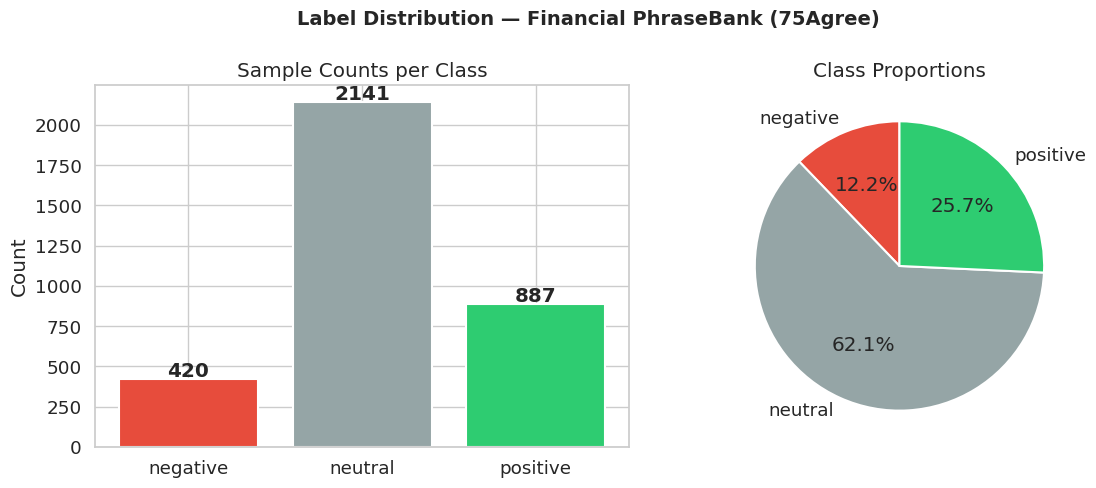

In [13]:
# Label distribution plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Label Distribution — Financial PhraseBank (75Agree)', fontsize=14, fontweight='bold')

counts = df_full['label'].value_counts()[LABEL_ORDER]

# Bar chart
axes[0].bar(counts.index, counts.values,
            color=[PALETTE[l] for l in counts.index], edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Sample Counts per Class')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[PALETTE[l] for l in counts.index],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Proportions')

plt.tight_layout()
save_fig('01_label_distribution.png')
plt.show()

  Saved to "/content/drive/MyDrive/CSCI 5541 Project/processed_data/eda_figures/02_sentence_length_by_label.png"


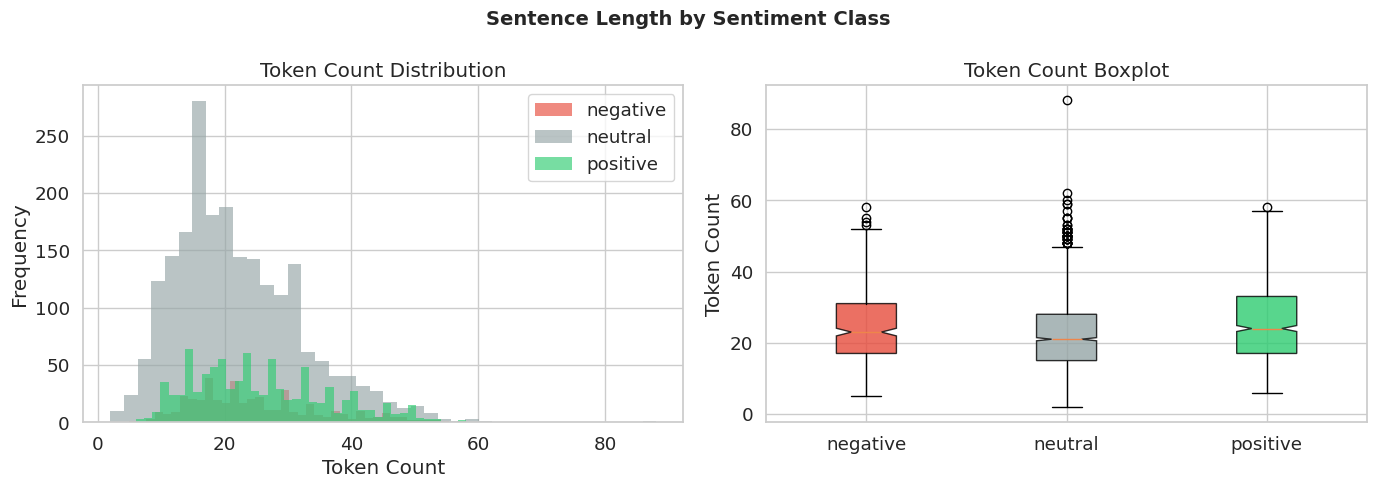

In [14]:
# Sentence length (# tokens) by label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentence Length by Sentiment Class', fontsize=14, fontweight='bold')

# Token count distribution
for label in LABEL_ORDER:
    subset = df_full[df_full['label'] == label]['token_count']
    axes[0].hist(subset, bins=40, alpha=0.65, label=label, color=PALETTE[label], edgecolor='none')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Token Count Distribution')
axes[0].legend()

# Boxplot
data_box = [df_full[df_full['label'] == l]['token_count'].values for l in LABEL_ORDER]
bp = axes[1].boxplot(data_box, labels=LABEL_ORDER, patch_artist=True, notch=True)
for patch, label in zip(bp['boxes'], LABEL_ORDER):
    patch.set_facecolor(PALETTE[label])
    patch.set_alpha(0.8)
axes[1].set_ylabel('Token Count')
axes[1].set_title('Token Count Boxplot')

plt.tight_layout()
save_fig('02_sentence_length_by_label.png')
plt.show()

  Saved to "/content/drive/MyDrive/CSCI 5541 Project/processed_data/eda_figures/03_feature_means_heatmap.png"


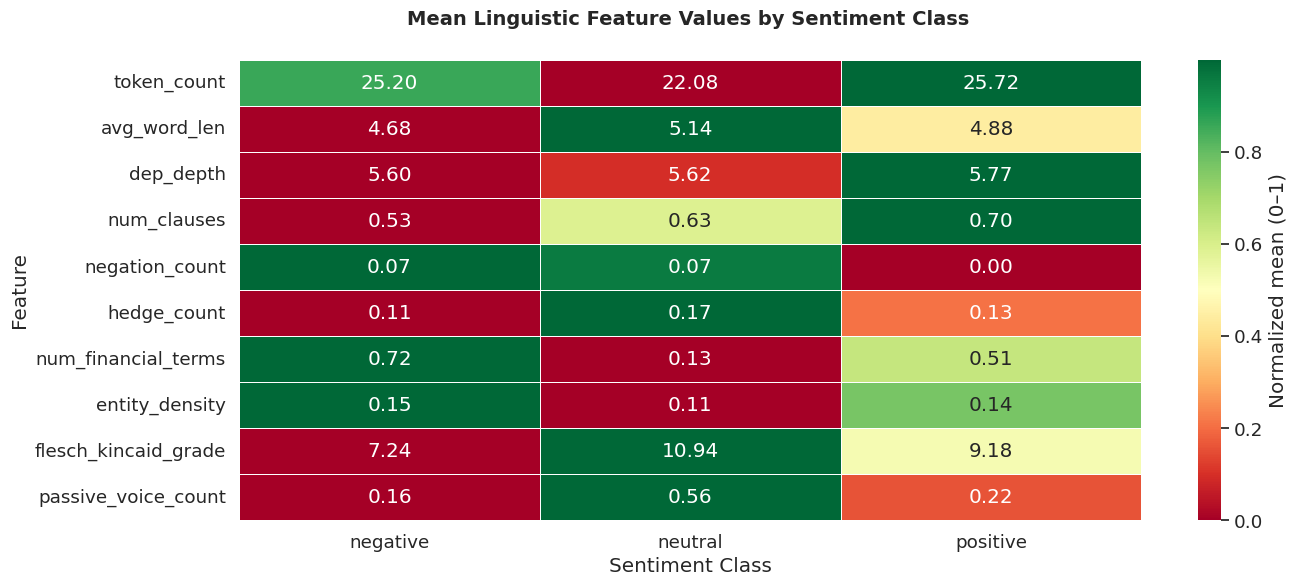

In [15]:
# Linguistic feature distribution by label
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Mean Linguistic Feature Values by Sentiment Class', fontsize=14, fontweight='bold')

plot_features = [
  'token_count', 'avg_word_len', 'dep_depth', 'num_clauses',
  'negation_count', 'hedge_count', 'num_financial_terms',
  'entity_density', 'flesch_kincaid_grade', 'passive_voice_count'
]

means = df_full.groupby('label')[plot_features].mean()
means_norm = (means - means.min()) / (means.max() - means.min() + 1e-9)  # normalize 0-1

sns.heatmap(
  means_norm.loc[LABEL_ORDER].T,
  annot=means.loc[LABEL_ORDER].T.round(2),
  fmt='.2f',
  cmap='RdYlGn',
  linewidths=0.5,
  ax=ax,
  cbar_kws={'label': 'Normalized mean (0–1)'}
)
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Feature')

plt.tight_layout()
save_fig('03_feature_means_heatmap.png')
plt.show()

  Saved to "/content/drive/MyDrive/CSCI 5541 Project/processed_data/eda_figures/04_hedge_negation_violins.png"


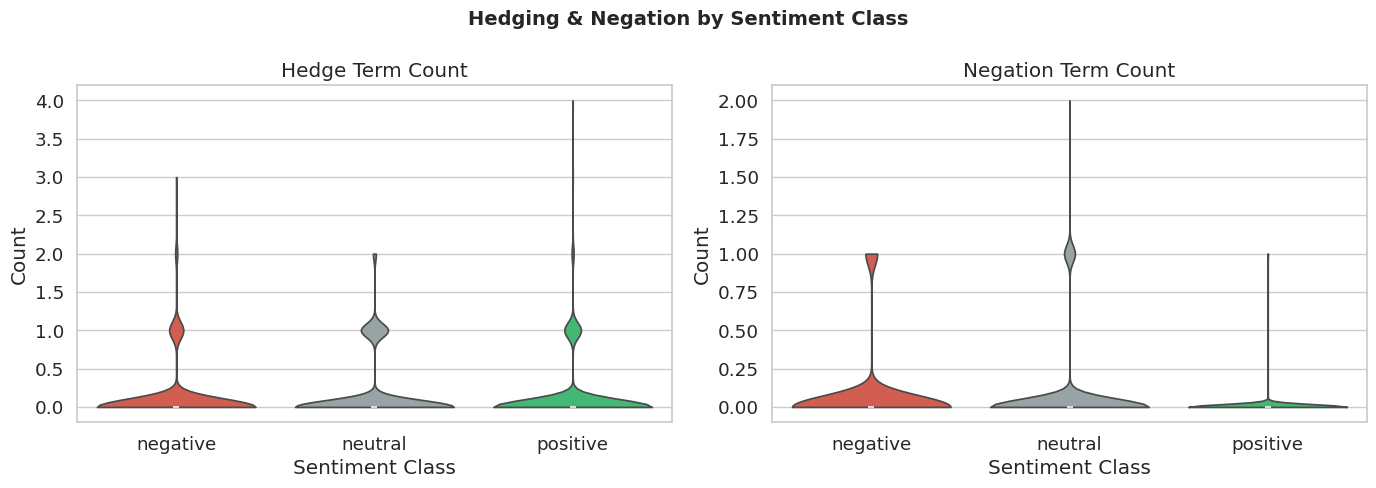

In [16]:
# Hedging and negation distributions by label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hedging & Negation by Sentiment Class', fontsize=14, fontweight='bold')

for ax, col, title in zip(
    axes,
    ['hedge_count', 'negation_count'],
    ['Hedge Term Count', 'Negation Term Count']
):
  sns.violinplot(
    data=df_full, x='label', y=col,
    order=LABEL_ORDER, palette=PALETTE,
    inner='box', ax=ax, cut=0
  )
  ax.set_title(title)
  ax.set_xlabel('Sentiment Class')
  ax.set_ylabel('Count')

plt.tight_layout()
save_fig('04_hedge_negation_violins.png')
plt.show()

  Saved to "/content/drive/MyDrive/CSCI 5541 Project/processed_data/eda_figures/05_syntactic_complexity.png"


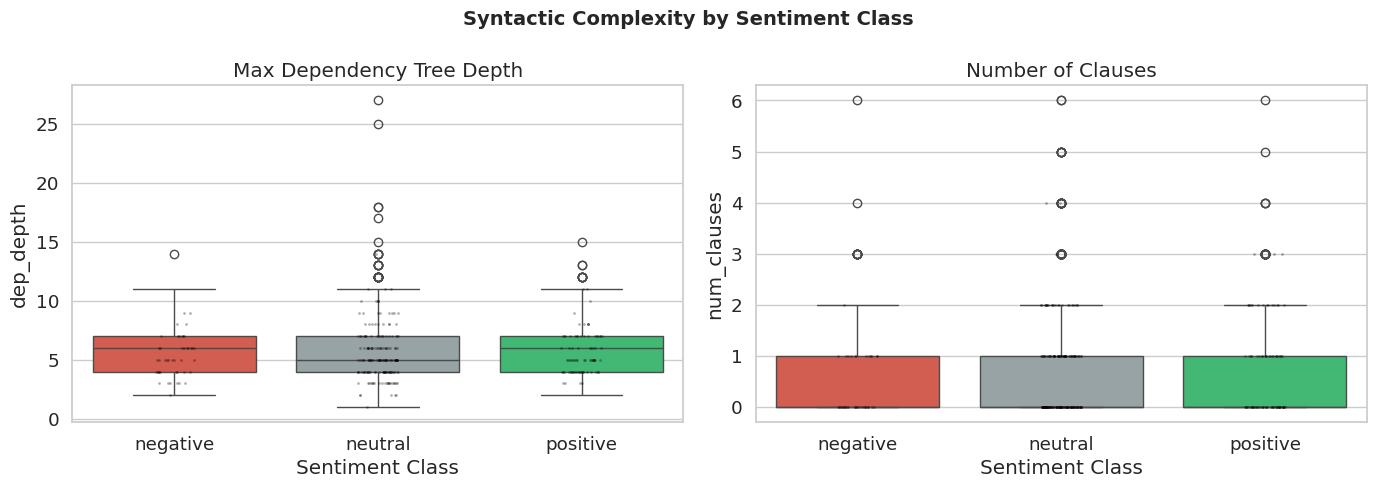

In [17]:
# Depth and clause complexity distribution by label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Syntactic Complexity by Sentiment Class', fontsize=14, fontweight='bold')

for ax, col, title in zip(
    axes,
    ['dep_depth', 'num_clauses'],
    ['Max Dependency Tree Depth', 'Number of Clauses']
):
  sns.boxplot(
    data=df_full, x='label', y=col,
    order=LABEL_ORDER, palette=PALETTE, ax=ax
  )
  sns.stripplot(
    data=df_full.sample(min(300, len(df_full))),
    x='label', y=col, order=LABEL_ORDER,
    color='black', alpha=0.3, size=2, ax=ax
  )
  ax.set_title(title)
  ax.set_xlabel('Sentiment Class')

plt.tight_layout()
save_fig('05_syntactic_complexity.png')
plt.show()

  Saved to "/content/drive/MyDrive/CSCI 5541 Project/processed_data/eda_figures/06_financial_term_density.png"


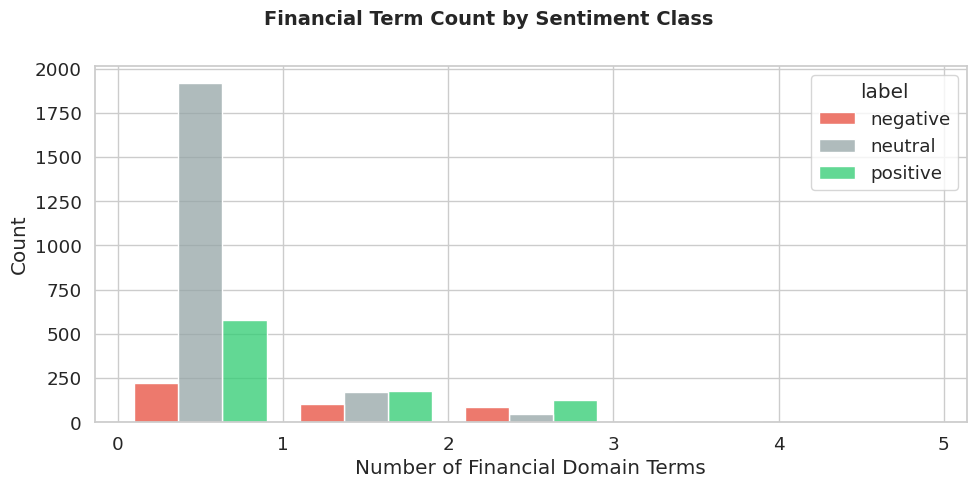

In [18]:
# Financial term density
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Financial Term Count by Sentiment Class', fontsize=14, fontweight='bold')

sns.histplot(
  data=df_full, x='num_financial_terms', hue='label',
  hue_order=LABEL_ORDER, palette=PALETTE,
  multiple='dodge', binwidth=1, ax=ax, shrink=0.8
)
ax.set_xlabel('Number of Financial Domain Terms')
ax.set_ylabel('Count')

plt.tight_layout()
save_fig('06_financial_term_density.png')
plt.show()

  Saved to "/content/drive/MyDrive/CSCI 5541 Project/processed_data/eda_figures/07_readability_scores.png"


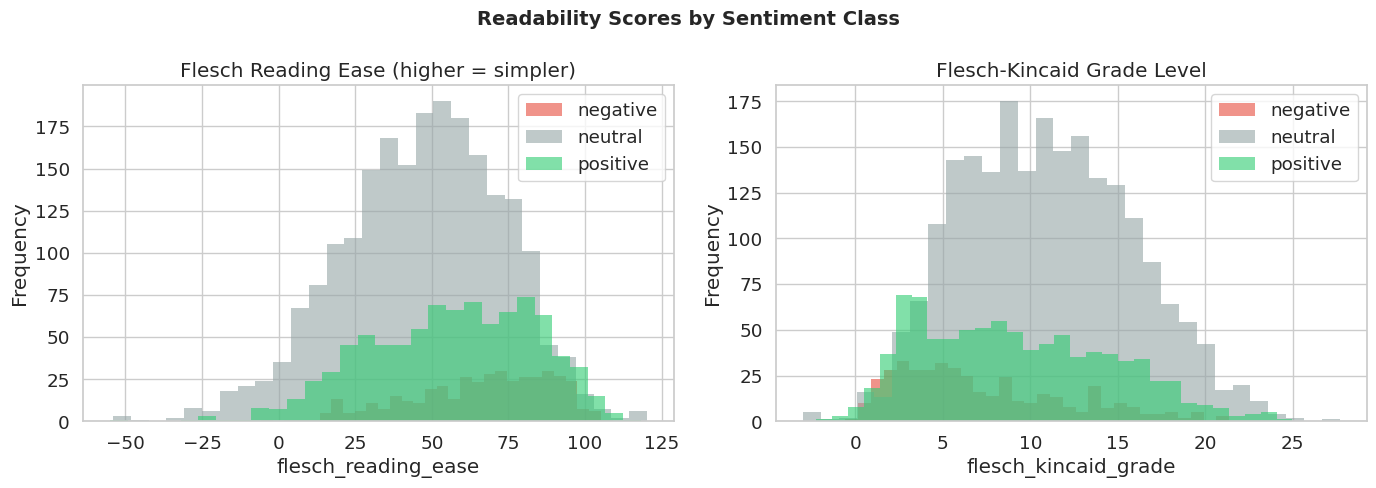

In [19]:
# Readability score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Readability Scores by Sentiment Class', fontsize=14, fontweight='bold')

for ax, col, title in zip(
    axes,
    ['flesch_reading_ease', 'flesch_kincaid_grade'],
    ['Flesch Reading Ease (higher = simpler)', 'Flesch-Kincaid Grade Level']
):
  for label in LABEL_ORDER:
    subset = df_full[df_full['label'] == label][col]
    ax.hist(subset, bins=30, alpha=0.6, label=label, color=PALETTE[label], edgecolor='none')

  ax.set_title(title)
  ax.set_xlabel(col)
  ax.set_ylabel('Frequency')
  ax.legend()

plt.tight_layout()
save_fig('07_readability_scores.png')
plt.show()

  Saved to "/content/drive/MyDrive/CSCI 5541 Project/processed_data/eda_figures/08_feature_correlation_matrix.png"


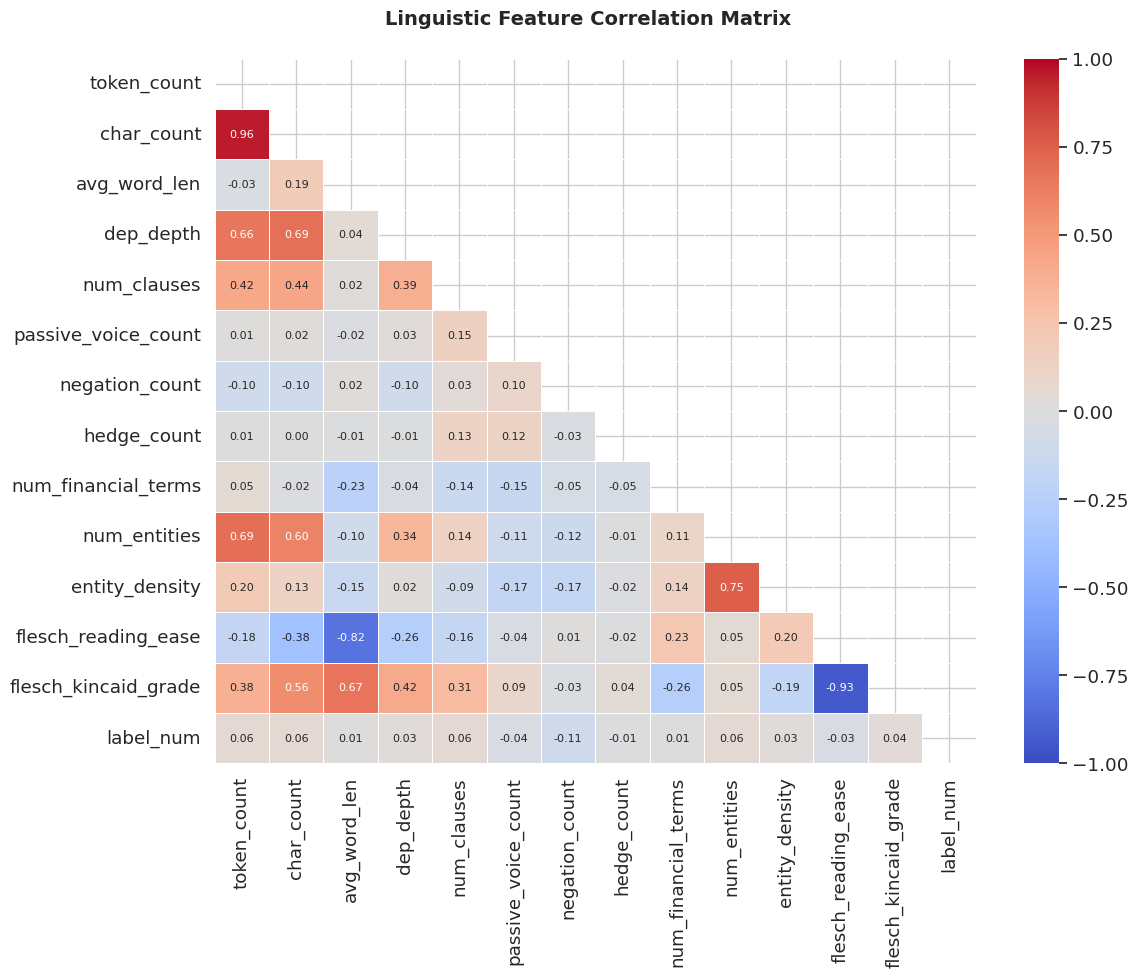

In [20]:
# Feature correlation
fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Linguistic Feature Correlation Matrix', fontsize=14, fontweight='bold')

# Map text labels to numbers just for the correlation calculation
label_to_num = {'negative': 0, 'neutral': 1, 'positive': 2}
corr_data = df_full[feature_cols].copy()
corr_data['label_num'] = df_full['label'].map(label_to_num)

# Calculate the correlation on numeric data
corr = corr_data.corr()

# Create the mask and plot
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
  corr, mask=mask, annot=True, fmt='.2f',
  cmap='coolwarm', center=0, vmin=-1, vmax=1,
  linewidths=0.4, ax=ax, annot_kws={'size': 8}
)

plt.tight_layout()
save_fig('08_feature_correlation_matrix.png')
plt.show()

  Saved to "/content/drive/MyDrive/CSCI 5541 Project/processed_data/eda_figures/09_complexity_score.png"


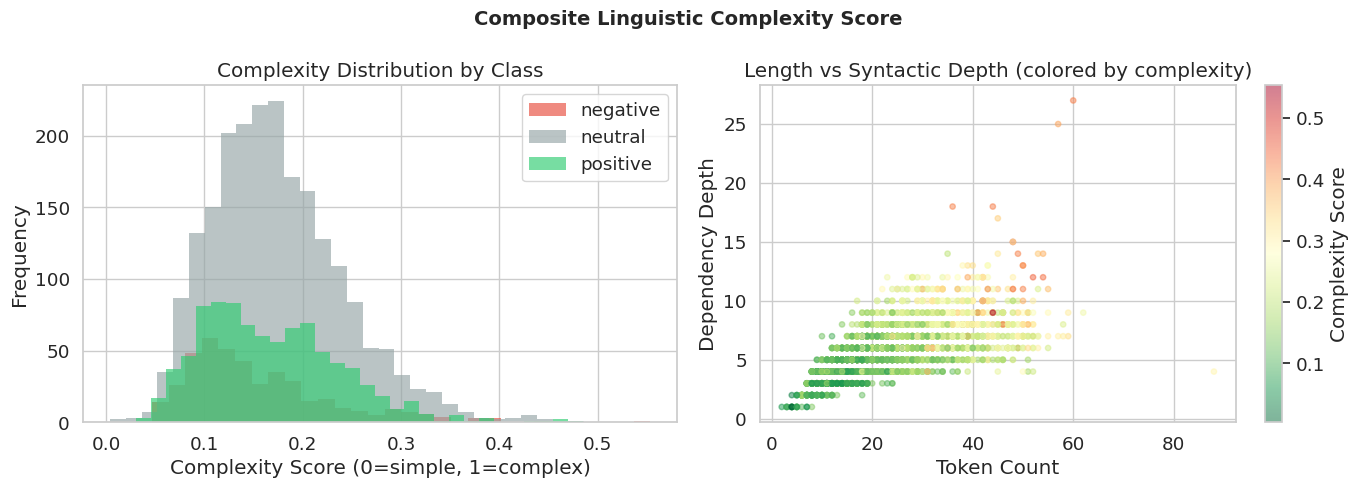


Median complexity score: 0.162
Top 10% most complex sentences (score > 0.261):


,sentence,label,complexity_score,token_count,dep_depth,hedge_count
3410,The steelmaker said that the drop in profit wa...,negative,0.553684,44,9,1
3421,Because expenditures must be justified to pass...,neutral,0.486394,42,10,1
59,The combination of all services enabling us to...,positive,0.485369,48,15,0
1133,"A Flurry Analytics spokesperson said that , as...",neutral,0.467582,40,8,0
650,"The planned facility , estimated to cost aroun...",positive,0.459040,38,8,4


In [21]:
# Composite complexity score
# Create a simple composite complexity score as a preview of what the router might
from sklearn.preprocessing import MinMaxScaler

complexity_features = [
  'token_count', 'dep_depth', 'num_clauses',
  'negation_count', 'hedge_count', 'flesch_kincaid_grade'
]
scaler = MinMaxScaler()
df_full['complexity_score'] = scaler.fit_transform(
    df_full[complexity_features]
).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Composite Linguistic Complexity Score', fontsize=14, fontweight='bold')

# Distribution by label
for label in LABEL_ORDER:
  axes[0].hist(
    df_full[df_full['label'] == label]['complexity_score'],
    bins=30, alpha=0.65, label=label, color=PALETTE[label], edgecolor='none'
  )

axes[0].set_xlabel('Complexity Score (0=simple, 1=complex)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Complexity Distribution by Class')
axes[0].legend()

# Scatter: complexity vs sentence length
sc = axes[1].scatter(
    df_full['token_count'],
    df_full['dep_depth'],
    c=df_full['complexity_score'],
    cmap='RdYlGn_r', alpha=0.5, s=15
)
plt.colorbar(sc, ax=axes[1], label='Complexity Score')
axes[1].set_xlabel('Token Count')
axes[1].set_ylabel('Dependency Depth')
axes[1].set_title('Length vs Syntactic Depth (colored by complexity)')

plt.tight_layout()
save_fig('09_complexity_score.png')
plt.show()
print(f'\nMedian complexity score: {df_full["complexity_score"].median():.3f}')
print(f'Top 10% most complex sentences (score > {df_full["complexity_score"].quantile(0.9):.3f}):')
display(df_full.nlargest(5, 'complexity_score')[['sentence', 'label', 'complexity_score',
                                                   'token_count', 'dep_depth', 'hedge_count']])

  Saved to "/content/drive/MyDrive/CSCI 5541 Project/processed_data/eda_figures/10_wordclouds.png"


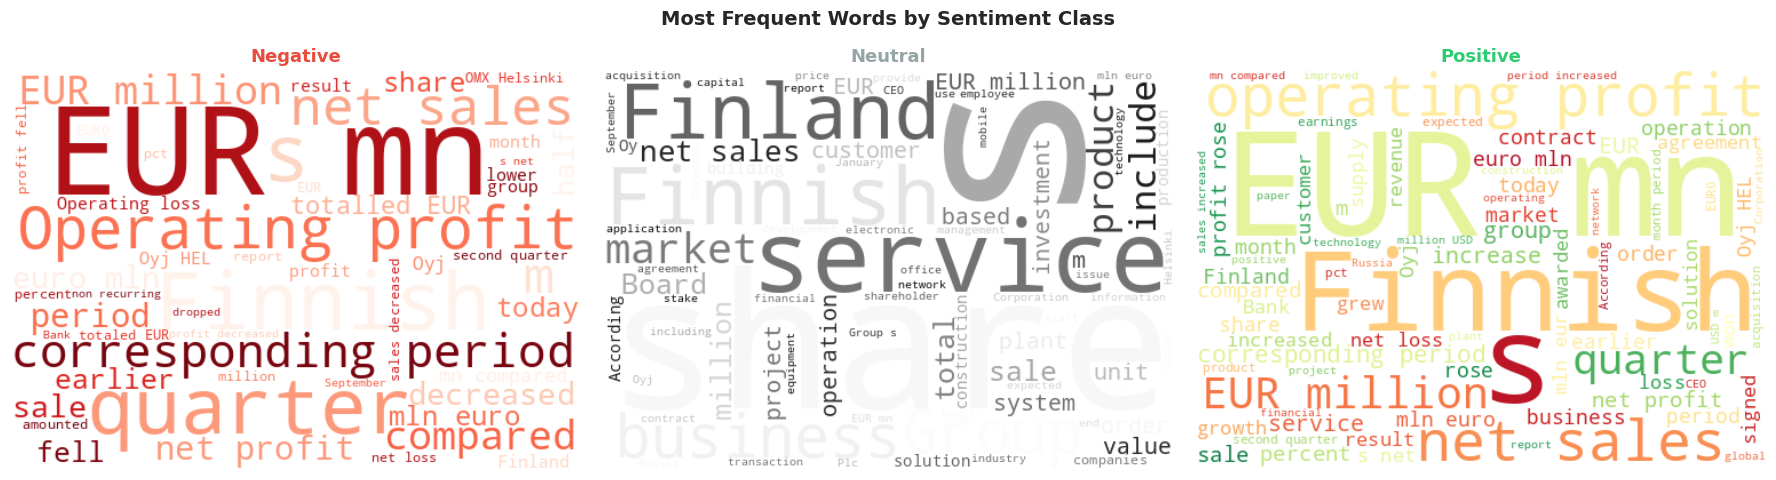

In [22]:
# Word clouds by label
import re
from collections import Counter

STOPWORDS = spacy.lang.en.stop_words.STOP_WORDS | {'company', 'said', 'also', 'year', 'new'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Most Frequent Words by Sentiment Class', fontsize=14, fontweight='bold')

for ax, label in zip(axes, LABEL_ORDER):
  text = ' '.join(df_full[df_full['label'] == label]['sentence'].tolist())
  wc = WordCloud(
    width=500, height=350, background_color='white',
    colormap='RdYlGn' if label == 'positive' else ('Reds' if label == 'negative' else 'Greys'),
    stopwords=STOPWORDS, max_words=80, min_font_size=10
  ).generate(text)
  ax.imshow(wc, interpolation='bilinear')
  ax.axis('off')
  ax.set_title(label.capitalize(), fontsize=13, fontweight='bold', color=PALETTE[label])

plt.tight_layout()
save_fig('10_wordclouds.png')
plt.show()

---
## 7. Stratified Train / Val / Test Split (70 / 15 / 15)

In [23]:
from sklearn.model_selection import train_test_split

# Split and get train (70%)
df_train, df_temp = train_test_split(
  df_full, test_size=0.30, random_state=5541, stratify=df_full['label']
)
# Split remaining into validation and test (15% and 15%)
df_val, df_test = train_test_split(
  df_temp, test_size=0.50, random_state=5541, stratify=df_temp['label']
)

print('Split Sizes')
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
  print(f'  {name:5s}: {len(split):4d} rows  |  '
      f'{split["label"].value_counts().to_dict()}')

# Verify no leakage
assert len(set(df_train.index) & set(df_test.index)) == 0, 'LEAKAGE: train/test overlap!'
assert len(set(df_val.index)   & set(df_test.index)) == 0, 'LEAKAGE: val/test overlap!'
print('No data leakage detected')

Split Sizes
  Train: 2413 rows  |  {'neutral': 1498, 'positive': 621, 'negative': 294}
  Val  :  517 rows  |  {'neutral': 321, 'positive': 133, 'negative': 63}
  Test :  518 rows  |  {'neutral': 322, 'positive': 133, 'negative': 63}
No data leakage detected


---
## 8. Save Processed Data to Google Drive

In [24]:
# Full processed dataset (with all features)
full_path  = os.path.join(OUTPUT_DIR, 'processed_phrasebank.csv')
train_path = os.path.join(OUTPUT_DIR, 'train.csv')
val_path   = os.path.join(OUTPUT_DIR, 'val.csv')
test_path  = os.path.join(OUTPUT_DIR, 'test.csv')

df_full.to_csv(full_path,  index=False)
df_train.to_csv(train_path, index=False)
df_val.to_csv(val_path,   index=False)
df_test.to_csv(test_path,  index=False)

print('Files Saved to Drive:')
for path, frame in [
  (full_path, df_full), (train_path, df_train),
  (val_path, df_val),   (test_path, df_test)
]:
  size_kb = os.path.getsize(path) / 1024
  print(f'  {os.path.basename(path):35s} {len(frame):5d} rows  {size_kb:.1f} KB')

print(f'\nAll outputs in: {OUTPUT_DIR}')

Files Saved to Drive:
  processed_phrasebank.csv             3448 rows  685.2 KB
  train.csv                            2413 rows  479.3 KB
  val.csv                               517 rows  103.3 KB
  test.csv                              518 rows  103.0 KB

All outputs in: /content/drive/MyDrive/CSCI 5541 Project/processed_data


---
## 9. Summary

In [25]:
print('=' * 60)
print('\tDATA PRE-PROCESSING SUMMARY')
print('=' * 60)
print(f'\tDataset          : Financial PhraseBank (sentences_75agree)')
print(f'\tTotal samples    : {len(df_full):,}')
print(f'\tTrain / Val / Test: {len(df_train)} / {len(df_val)} / {len(df_test)}')
print(f'\tLinguistic features extracted: {len(feature_cols)}')
print(f'\tEDA figures saved: {len(os.listdir(FIG_DIR))}')
print()
print('\tKey Findings (preview for router motivation):')

for label in LABEL_ORDER:
  sub = df_full[df_full['label'] == label]
  print(f'\t[{label:8s}]  avg tokens={sub["token_count"].mean():.1f}  '
      f'avg hedges={sub["hedge_count"].mean():.2f}  '
      f'avg dep_depth={sub["dep_depth"].mean():.1f}  '
      f'complexity={sub["complexity_score"].mean():.3f}')

print('=' * 60)

	DATA PRE-PROCESSING SUMMARY
	Dataset          : Financial PhraseBank (sentences_75agree)
	Total samples    : 3,448
	Train / Val / Test: 2413 / 517 / 518
	Linguistic features extracted: 13
	EDA figures saved: 10

	Key Findings (preview for router motivation):
	[negative]  avg tokens=25.2  avg hedges=0.11  avg dep_depth=5.6  complexity=0.155
	[neutral ]  avg tokens=22.1  avg hedges=0.17  avg dep_depth=5.6  complexity=0.174
	[positive]  avg tokens=25.7  avg hedges=0.13  avg dep_depth=5.8  complexity=0.168
